# ***Encoding***
My name is **Joselyne**, and this is *a simple encoding practice* on house price prediction with a focus on categorical encoding (One-Hot vs Label Encoding) using Linear Regression and Random Forest.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn 


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


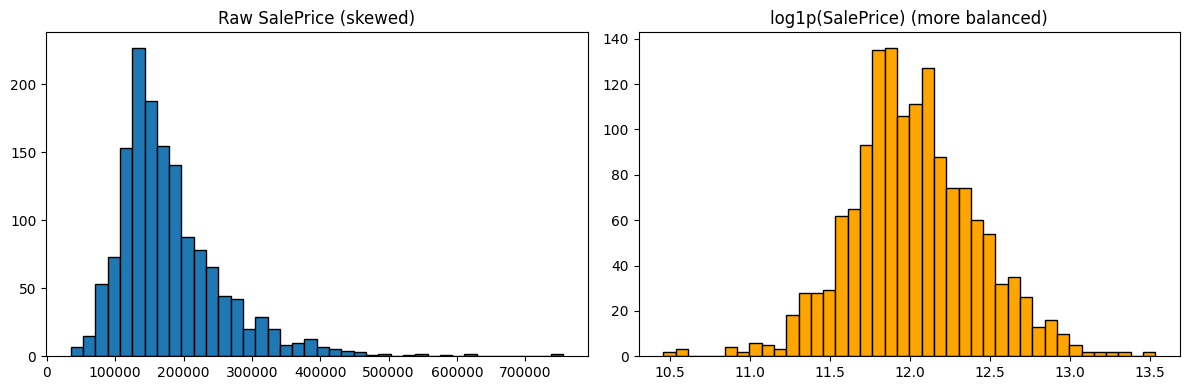

In [4]:
y_log = np.log1p(train['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train['SalePrice'], bins=40, edgecolor='black')
axes[0].set_title("Raw SalePrice (skewed)")
axes[1].hist(y_log, bins=40, edgecolor='black', color='orange')
axes[1].set_title("log1p(SalePrice) (more balanced)")
plt.tight_layout()
plt.show()

In [5]:
train_features = train.drop(columns=['SalePrice'])
train_features['is_train'] = 1
test['is_train'] = 0
all_data = pd.concat([train_features, test], sort=False)

In [6]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

In [7]:
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2',
             'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

In [8]:
for col in all_data.columns:
    if all_data[col].dtype == 'object':
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])
    else:
        all_data[col] = all_data[col].fillna(all_data[col].median())


In [9]:
print("Any missing values left?", all_data.isnull().sum().sum())

Any missing values left? 0


In [10]:
import seaborn as sns

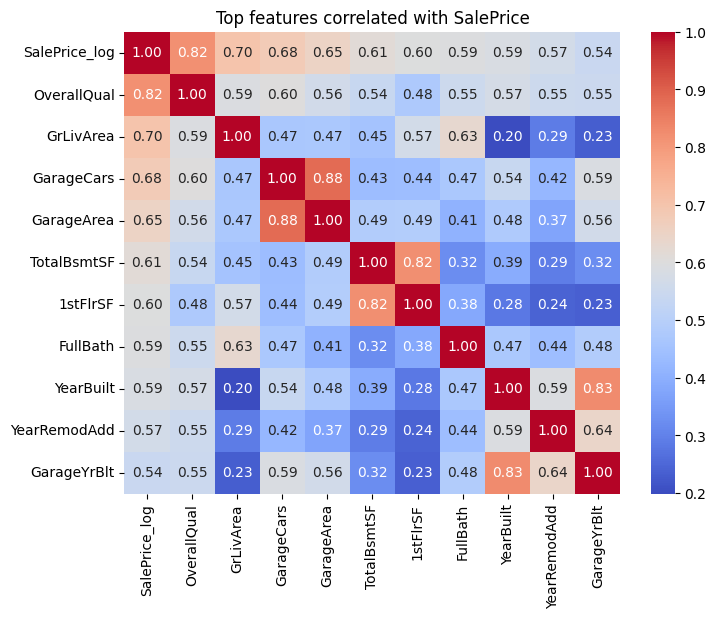

In [11]:
numeric_cols = train.select_dtypes(include=[np.number]).drop(columns=['Id', 'SalePrice']).columns
corr_data = train[numeric_cols].copy()
corr_data['SalePrice_log'] = y_log
corr = corr_data.corr()

top_corr = corr['SalePrice_log'].abs().sort_values(ascending=False).head(11).index
plt.figure(figsize=(8, 6))
sns.heatmap(corr.loc[top_corr, top_corr], annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Top features correlated with SalePrice")
plt.show()

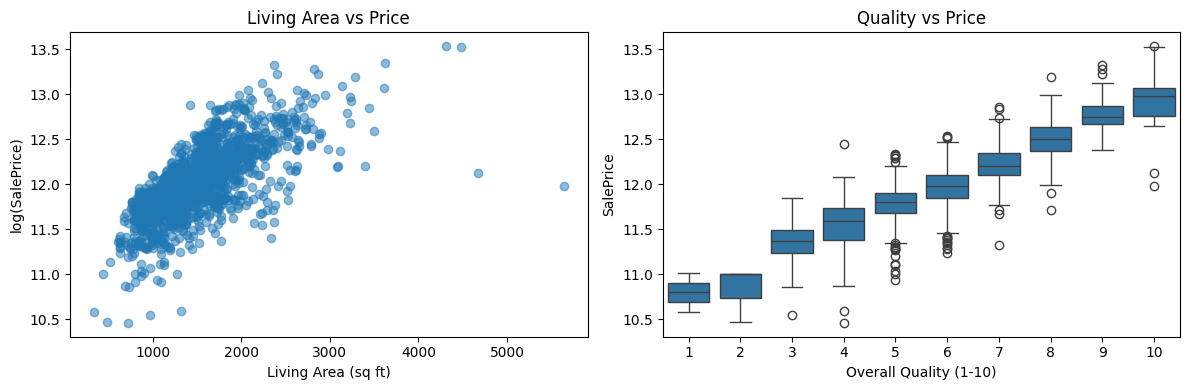

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(train['GrLivArea'], y_log, alpha=0.5)
axes[0].set_xlabel("Living Area (sq ft)")
axes[0].set_ylabel("log(SalePrice)")
axes[0].set_title("Living Area vs Price")

sns.boxplot(x=train['OverallQual'], y=y_log, ax=axes[1])
axes[1].set_xlabel("Overall Quality (1-10)")
axes[1].set_title("Quality vs Price")

plt.tight_layout()
plt.show()

In [13]:
all_data_encoded = pd.get_dummies(all_data, drop_first=True)

train_clean = all_data_encoded[all_data_encoded['is_train'] == 1].drop(columns=['is_train'])
test_clean = all_data_encoded[all_data_encoded['is_train'] == 0].drop(columns=['is_train'])

print(train_clean.shape, test_clean.shape)

(1460, 260) (1459, 260)


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_val, y_train, y_val = train_test_split(
    train_clean, y_log, test_size=0.2, random_state=42
)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
pred_val_lr = model_lr.predict(X_val)

rmse_lr = np.sqrt(mean_squared_error(y_val, pred_val_lr))
print("Linear Regression RMSE:", rmse_lr)

Linear Regression RMSE: 0.1731948203179715


In [15]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=300, random_state=42)
model_rf.fit(X_train, y_train)
pred_val_rf = model_rf.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, pred_val_rf))
print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 0.14854659668476256


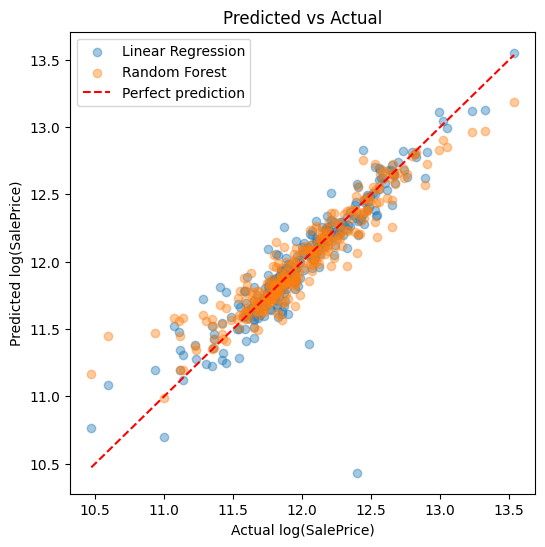

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(y_val, pred_val_lr, alpha=0.4, label='Linear Regression')
plt.scatter(y_val, pred_val_rf, alpha=0.4, label='Random Forest')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', label='Perfect prediction')
plt.xlabel("Actual log(SalePrice)")
plt.ylabel("Predicted log(SalePrice)")
plt.legend()
plt.title("Predicted vs Actual")
plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder

all_data_encoded = all_data.copy()

cat_cols = all_data_encoded.select_dtypes(include='object').columns

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    all_data_encoded[col] = le.fit_transform(all_data_encoded[col].astype(str))
    label_encoders[col] = le  # save it in case you need to decode later

print("Categorical columns encoded:", len(cat_cols))
print(all_data_encoded.shape)

Categorical columns encoded: 43
(2919, 81)


In [18]:
train_clean = all_data_encoded[all_data_encoded['is_train'] == 1].drop(columns=['is_train'])
test_clean = all_data_encoded[all_data_encoded['is_train'] == 0].drop(columns=['is_train'])

print(train_clean.shape, test_clean.shape)

(1460, 80) (1459, 80)


In [19]:
final_model = RandomForestRegressor(n_estimators=300, random_state=42)
final_model.fit(train_clean, y_log) 

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
test_pred_log = final_model.predict(test_clean)
test_pred = np.expm1(test_pred_log)
print(test_pred[:10])  

[123719.54842377 153010.03873477 177865.87044797 179209.70449464
 196026.92638049 182244.32828674 162394.43787602 174826.96314341
 183308.23786123 124402.66685162]


In [21]:
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': test_pred
})

submission.to_csv('submission.csv', index=False)
submission.head()

,Id,SalePrice
0,1461,123719.548424
1,1462,153010.038735
2,1463,177865.870448
3,1464,179209.704495
4,1465,196026.926380


One-Hot vs Label Encoding

In [23]:
from sklearn.preprocessing import LabelEncoder

all_data_encoded = all_data.copy()

cat_cols = all_data_encoded.select_dtypes(include='object').columns

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    all_data_encoded[col] = le.fit_transform(all_data_encoded[col].astype(str))
    label_encoders[col] = le  

print("Categorical columns encoded:", len(cat_cols))
print(all_data_encoded.shape)

Categorical columns encoded: 43
(2919, 81)


In [24]:
train_clean = all_data_encoded[all_data_encoded['is_train'] == 1].drop(columns=['is_train'])
test_clean = all_data_encoded[all_data_encoded['is_train'] == 0].drop(columns=['is_train'])

print(train_clean.shape, test_clean.shape)

(1460, 80) (1459, 80)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_clean, y_log, test_size=0.2, random_state=42
)

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
pred_val_lr = model_lr.predict(X_val)

model_rf = RandomForestRegressor(n_estimators=300, random_state=42)
model_rf.fit(X_train, y_train)
pred_val_rf = model_rf.predict(X_val)

In [27]:
from sklearn.metrics import mean_squared_error, r2_score

rmse_lr = np.sqrt(mean_squared_error(y_val, pred_val_lr))
rmse_rf = np.sqrt(mean_squared_error(y_val, pred_val_rf))

r2_lr = r2_score(y_val, pred_val_lr)
r2_rf = r2_score(y_val, pred_val_rf)

print("Linear Regression_RMSE:", rmse_lr, " R²:", r2_lr)
print("Random Forest_RMSE:", rmse_rf, " R²:", r2_rf)

Linear Regression_RMSE: 0.15642986164215403  R²: 0.8688699856401608
Random Forest_RMSE: 0.1459538055699823  R²: 0.885845343184617


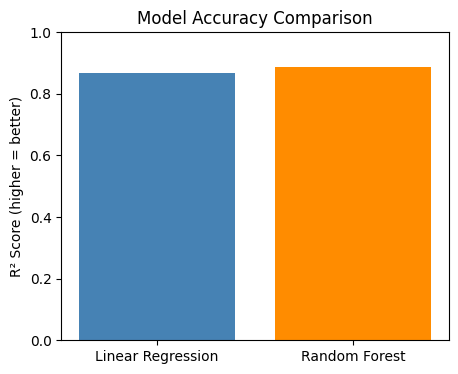

In [29]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Random Forest']
r2_scores = [r2_lr, r2_rf]

plt.figure(figsize=(5, 4))
plt.bar(models, r2_scores, color=['steelblue', 'darkorange'])
plt.ylabel("R² Score (higher = better)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

## Summary

This project predicts house sale prices using the Kaggle "House Prices: Advanced Regression Techniques" dataset (1460 training rows, 1459 test rows, 80 features).

**Workflow:**
1. Explored the dataset and log-transformed `SalePrice` to correct its right-skewed distribution and align with the competition's RMSE(log) scoring metric.
2. Cleaned missing values — distinguishing columns where NA means "feature absent" (e.g. no pool, no fence) from columns with genuinely unknown values, using `data_description.txt` as the source of truth.
3. Visualized the data: missing-value counts, correlation heatmap, and scatter/box plots of key features (`GrLivArea`, `OverallQual`) against price.
4. Encoded categorical features using Label Encoding.
5. Trained and compared two models: **Linear Regression** (baseline) and **Random Forest** (300 trees).
6. Evaluated both models using RMSE and R² on a held-out validation split, and visualized predicted vs. actual prices.
7. Retrained the best-performing model (Random Forest) on the full training set and generated predictions for `test.csv`.

I tried two approaches. One-Hot Encoding created a separate 0/1 column per category, avoiding any false sense of order — safer for Linear Regression but it widened the dataset considerably. Label Encoding replaced each category with a single number, keeping the dataset compact and working well with the tree-based splits in Random Forest, but it risks implying a ranking between categories (e.g. neighborhoods) that doesn't really exist. For this dataset, Label Encoding paired better with Random Forest, while One-Hot was the more principled choice for Linear Regression.